# PRCP-1018— Bike Rental -Capstone Project
### Step-by-Step Code 

**Dataset:** Capital Bikeshare, Washington D.C. (2011–2012)  
**Files needed:** `day.csv` and `hour.csv` (place in same folder as this notebook)

---
| Step | What We Do |
|------|------------|
| Step 1 | Import Libraries |
| Step 2 | Load the Data |
| Step 3 | Understand the Data |
| Step 4 | Clean the Data |
| Step 5 | Basic Statistics |
| Step 6 | Chart 1 — Monthly Trend |
| Step 7 | Chart 2 — Rentals by Season |
| Step 8 | Chart 3 — Casual vs Registered Users |
| Step 9 | Chart 4 — Hourly Pattern |
| Step 10 | Chart 5 — Weather Effect |
| Step 11 | Prepare Data for ML |
| Step 12 | Linear Regression Model |
| Step 13 | Random Forest Model |
| Step 14 | Compare Both Models |
| Step 15 | Actual vs Predicted Chart |
| Step 16 | Final Summary |

---
## ✅ STEP 1 — Import Libraries

First we need to import all the Python libraries we will use in this project.  
Think of libraries as **toolboxes** — each one gives us special tools.

| Library | What it does |
|---------|-------------|
| `pandas` | Load and work with data (like Excel in Python) |
| `numpy` | Do math calculations |
| `matplotlib` | Draw charts and graphs |
| `seaborn` | Draw nicer-looking charts |
| `sklearn` | Build machine learning models |

In [1]:
# Import libraries for data handling
import pandas as pd
import numpy as np

# Import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# This line makes charts appear inside the notebook
%matplotlib inline

# Import libraries for machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# This hides unnecessary warning messages
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!



## ✅ STEP 2 — Load the Data

We will load the two CSV files into pandas DataFrames.  
A **DataFrame** is like a table — it has rows and columns.

> Make sure `day.csv` and `hour.csv` are in the **same folder** as this notebook!

In [2]:
# Load the daily dataset
day = pd.read_csv('day.csv')

# Load the hourly dataset
hour = pd.read_csv('hour.csv')

# Print how many rows and columns each file has
print('day.csv  loaded:', day.shape[0], 'rows and', day.shape[1], 'columns')
print('hour.csv loaded:', hour.shape[0], 'rows and', hour.shape[1], 'columns')

day.csv  loaded: 731 rows and 16 columns
hour.csv loaded: 17379 rows and 17 columns


In [3]:
# Look at the first 5 rows of the daily dataset
# This helps us see what the data looks like
print('First 5 rows of day.csv:')
day.head()

First 5 rows of day.csv:


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2011,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,02-01-2011,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,03-01-2011,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,04-01-2011,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,05-01-2011,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


---
## ✅ STEP 3 — Understand the Data

Before we do anything, we need to understand what data we have.  
We will check:
- Column names and data types
- How many missing values are there
- Basic statistics (min, max, average)

In [4]:
# See all column names and their data types
print('Column names and data types:')
print(day.dtypes)

Column names and data types:
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object


In [5]:
# Check for missing values in each column
# A value of 0 means no missing values in that column
print('Missing values in each column:')
print(day.isnull().sum())

Missing values in each column:
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [6]:
# Check for duplicate rows
print('Number of duplicate rows:', day.duplicated().sum())

Number of duplicate rows: 0


In [7]:
# Get basic statistics for all numeric columns
# This shows min, max, average, etc.
print('Basic statistics:')
day.describe().round(2)

Basic statistics:


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.00,731.00,731.0,731.00,731.00,731.0,731.00,731.00,731.00,731.00,731.00,731.00,731.00,731.00,731.00
mean,366.00,2.50,0.5,6.52,0.03,3.0,0.68,1.40,0.50,0.47,0.63,0.19,848.18,3656.17,4504.35
std,211.17,1.11,0.5,3.45,0.17,2.0,0.47,0.54,0.18,0.16,0.14,0.08,686.62,1560.26,1937.21
min,1.00,1.00,0.0,1.00,0.00,0.0,0.00,1.00,0.06,0.08,0.00,0.02,2.00,20.00,22.00
25%,183.50,2.00,0.0,4.00,0.00,1.0,0.00,1.00,0.34,0.34,0.52,0.13,315.50,2497.00,3152.00
50%,366.00,3.00,1.0,7.00,0.00,3.0,1.00,1.00,0.50,0.49,0.63,0.18,713.00,3662.00,4548.00
75%,548.50,3.00,1.0,10.00,0.00,5.0,1.00,2.00,0.66,0.61,0.73,0.23,1096.00,4776.50,5956.00
max,731.00,4.00,1.0,12.00,1.00,6.0,1.00,3.00,0.86,0.84,0.97,0.51,3410.00,6946.00,8714.00


---
## ✅ STEP 4 — Clean the Data

The data is already clean (no missing values).  

In [8]:
# Add a new column 'season_name' with readable season names
# 1 = Spring, 2 = Summer, 3 = Fall, 4 = Winter
day['season_name'] = day['season'].map({
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
})

print('Season labels added!')
print(day['season_name'].value_counts())

Season labels added!
season_name
Fall      188
Summer    184
Spring    181
Winter    178
Name: count, dtype: int64


In [9]:
# Add a new column 'weather_name' with readable weather names
day['weather_name'] = day['weathersit'].map({
    1: 'Clear',
    2: 'Mist',
    3: 'Light Rain',
    4: 'Heavy Rain'
})

print('Weather labels added!')
print(day['weather_name'].value_counts())

Weather labels added!
weather_name
Clear         463
Mist          247
Light Rain     21
Name: count, dtype: int64


In [10]:
# Add a new column 'weekday_name' with readable day names
day['weekday_name'] = day['weekday'].map({
    0: 'Sun', 1: 'Mon', 2: 'Tue',
    3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'
})

print('Weekday labels added!')

Weekday labels added!


In [11]:
# Convert the 'dteday' column to proper date format
day['date'] = pd.to_datetime(day['dteday'], dayfirst=True)

# Extract year and month as separate columns (useful for grouping)
day['year']  = day['date'].dt.year
day['month'] = day['date'].dt.month

print('Date column converted!')
print('Year values:', day['year'].unique())
print('Month values:', sorted(day['month'].unique()))

Date column converted!
Year values: [2011 2012]
Month values: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]


In [12]:
# The temperature column is normalized (0 to 1)
# Multiply by 41 to get actual Celsius temperature
day['temp_celsius'] = day['temp'] * 41

# Do the same for humidity (multiply by 100 to get percentage)
day['hum_percent'] = day['hum'] * 100

print('Temperature and humidity converted to readable units!')
print('Temperature range:', round(day['temp_celsius'].min(), 1), 'to', round(day['temp_celsius'].max(), 1), 'degrees C')

Temperature and humidity converted to readable units!
Temperature range: 2.4 to 35.3 degrees C


In [13]:
# Apply the same labels to hour.csv as well
hour['season_name'] = hour['season'].map({1:'Spring', 2:'Summer', 3:'Fall', 4:'Winter'})
hour['weather_name'] = hour['weathersit'].map({1:'Clear', 2:'Mist', 3:'Light Rain', 4:'Heavy Rain'})

print('Labels added to hour.csv too!')
print('Cleaning complete. Data is ready for analysis.')

Labels added to hour.csv too!
Cleaning complete. Data is ready for analysis.


---
## ✅ STEP 5 — Basic Statistics

Let us print some basic numbers about the dataset  
before we start making charts.

In [14]:
# Print key numbers about the dataset
print('========== BASIC STATISTICS ==========')
print()

total_rentals = day['cnt'].sum()
print('Total bike rentals (2011-2012):', total_rentals)

avg_per_day = round(day['cnt'].mean(), 1)
print('Average rentals per day:', avg_per_day)

max_day = day['cnt'].max()
print('Maximum rentals in a single day:', max_day)

min_day = day['cnt'].min()
print('Minimum rentals in a single day:', min_day)

print()

casual_total = day['casual'].sum()
registered_total = day['registered'].sum()
casual_pct = round(casual_total / total_rentals * 100, 1)
registered_pct = round(registered_total / total_rentals * 100, 1)

print('Casual user rentals:', casual_total, f'({casual_pct}%)')
print('Registered user rentals:', registered_total, f'({registered_pct}%)')

print()
print('======================================')

========== BASIC STATISTICS ==========

Total bike rentals (2011-2012): 3292679
Average rentals per day: 4504.3
Maximum rentals in a single day: 8714
Minimum rentals in a single day: 22

Casual user rentals: 620017 (18.8%)
Registered user rentals: 2672662 (81.2%)



---
## ✅ STEP 6 — Chart 1: Monthly Rental Trend

This chart shows how total bike rentals changed every month  
from January 2011 to December 2012.

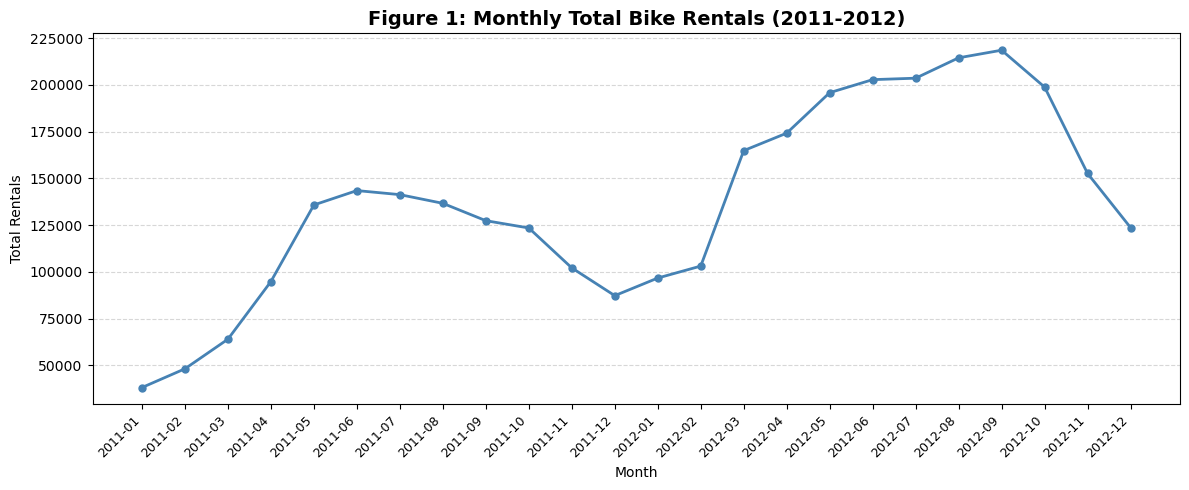

Observation: Rentals increased from 2011 to 2012.
Rentals are higher in middle months (summer/fall) and lower in winter.


In [15]:
# Group data by year and month, then sum the rentals
monthly = day.groupby(['year', 'month'])['cnt'].sum().reset_index()

# Create a label like '2011-01', '2011-02' etc. for the x-axis
monthly['period'] = (monthly['year'].astype(str) + '-' +
                     monthly['month'].astype(str).str.zfill(2))

# Create the chart
plt.figure(figsize=(12, 5))

# Draw the line
plt.plot(range(len(monthly)), monthly['cnt'],
         color='steelblue', linewidth=2, marker='o', markersize=5)

# Add labels to x-axis
plt.xticks(range(len(monthly)), monthly['period'], rotation=45, ha='right', fontsize=9)

# Add title and axis labels
plt.title('Figure 1: Monthly Total Bike Rentals (2011-2012)', fontsize=14, fontweight='bold')
plt.ylabel('Total Rentals')
plt.xlabel('Month')

# Add horizontal grid lines to make reading easier
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print('Observation: Rentals increased from 2011 to 2012.')
print('Rentals are higher in middle months (summer/fall) and lower in winter.')

---
## ✅ STEP 7 — Chart 2: Rentals by Season

This bar chart shows which season has the most bike rentals on average.

In [16]:
# Calculate the average daily rentals for each season
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_avg = day.groupby('season_name')['cnt'].mean().reindex(season_order)

print('Average daily rentals by season:')
for season, avg in season_avg.items():
    print(f'  {season}: {avg:.0f} rentals/day')

Average daily rentals by season:
  Spring: 2604 rentals/day
  Summer: 4992 rentals/day
  Fall: 5644 rentals/day
  Winter: 4728 rentals/day


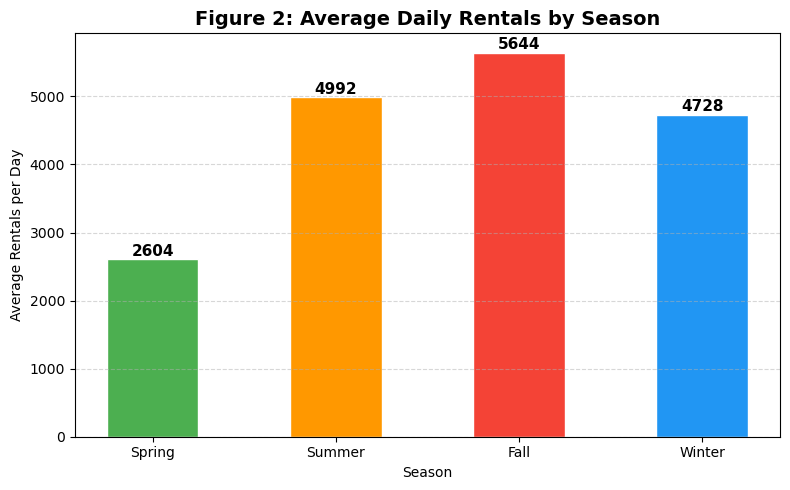

Observation: Fall has the most rentals. Winter has the least.
People prefer riding bikes in comfortable weather.


In [17]:
# Create the bar chart
plt.figure(figsize=(8, 5))

# Draw bars with different colors for each season
colors = ['#4CAF50', '#FF9800', '#F44336', '#2196F3']
bars = plt.bar(season_avg.index, season_avg.values, color=colors, width=0.5, edgecolor='white')

# Add the value on top of each bar
for bar, val in zip(bars, season_avg.values):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 50,
             str(round(val)),
             ha='center', fontsize=11, fontweight='bold')

# Add title and labels
plt.title('Figure 2: Average Daily Rentals by Season', fontsize=14, fontweight='bold')
plt.ylabel('Average Rentals per Day')
plt.xlabel('Season')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print('Observation: Fall has the most rentals. Winter has the least.')
print('People prefer riding bikes in comfortable weather.')

---
## ✅ STEP 8 — Chart 3: Casual vs Registered Users

This pie chart shows what percentage of rentals are done  
by casual users vs registered users.

In [18]:
# Calculate total rentals for each user type
casual_total     = day['casual'].sum()
registered_total = day['registered'].sum()

print('Total casual user rentals    :', casual_total)
print('Total registered user rentals:', registered_total)

Total casual user rentals    : 620017
Total registered user rentals: 2672662


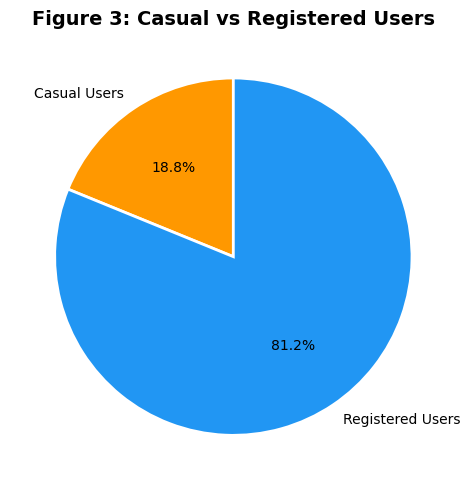

Observation: 81.2% of rentals are by registered users.
Most users are regular commuters, not tourists.


In [19]:
# Create the pie chart
plt.figure(figsize=(7, 5))

plt.pie(
    [casual_total, registered_total],
    labels=['Casual Users', 'Registered Users'],
    colors=['#FF9800', '#2196F3'],
    autopct='%1.1f%%',        # Show percentage on each slice
    startangle=90,            # Start from top
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

plt.title('Figure 3: Casual vs Registered Users', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print('Observation: 81.2% of rentals are by registered users.')
print('Most users are regular commuters, not tourists.')

---
## ✅ STEP 9 — Chart 4: Hourly Rental Pattern

This chart uses the **hour.csv** file.  
It shows how rentals change throughout the day  
for casual and registered users separately.

In [20]:
# Calculate average rentals for each hour of the day
# Separately for casual and registered users
hourly_casual     = hour.groupby('hr')['casual'].mean()
hourly_registered = hour.groupby('hr')['registered'].mean()

print('Average casual rentals at 8 AM     :', round(hourly_casual[8], 1))
print('Average registered rentals at 8 AM :', round(hourly_registered[8], 1))
print()
print('Average casual rentals at 5 PM     :', round(hourly_casual[17], 1))
print('Average registered rentals at 5 PM :', round(hourly_registered[17], 1))

Average casual rentals at 8 AM     : 21.7
Average registered rentals at 8 AM : 337.3

Average casual rentals at 5 PM     : 74.3
Average registered rentals at 5 PM : 387.2


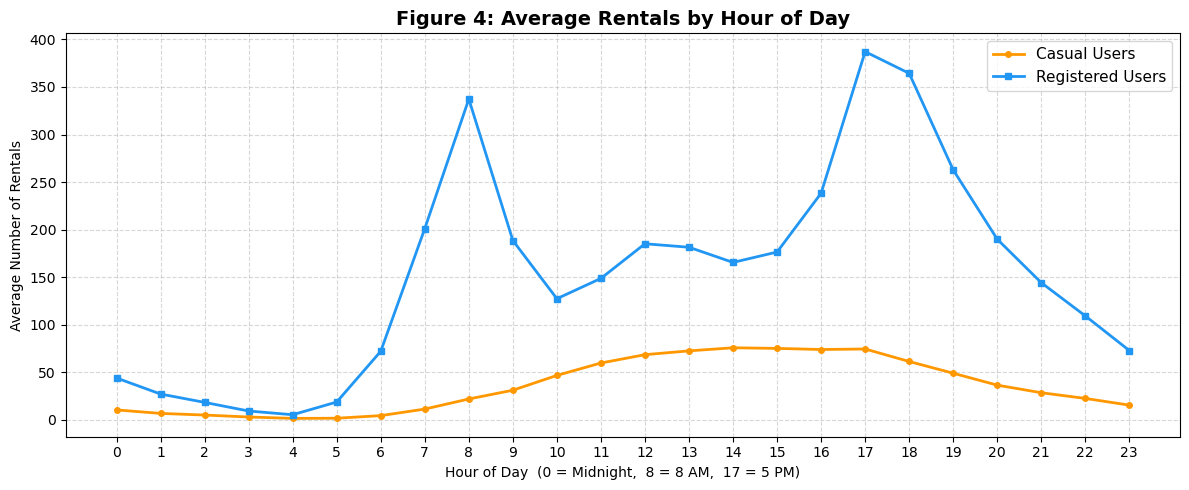

Observation:
  Registered users peak at 8 AM and 5-6 PM  → they are office commuters
  Casual users peak around 12 PM to 3 PM    → they use bikes for leisure


In [21]:
# Create the line chart
plt.figure(figsize=(12, 5))

# Plot casual users line
plt.plot(hourly_casual.index, hourly_casual.values,
         color='#FF9800', linewidth=2, marker='o', markersize=4, label='Casual Users')

# Plot registered users line
plt.plot(hourly_registered.index, hourly_registered.values,
         color='#2196F3', linewidth=2, marker='s', markersize=4, label='Registered Users')

# Show all 24 hours on x-axis
plt.xticks(range(0, 24))

# Add title, labels, legend
plt.title('Figure 4: Average Rentals by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day  (0 = Midnight,  8 = 8 AM,  17 = 5 PM)')
plt.ylabel('Average Number of Rentals')
plt.legend(fontsize=11)
plt.grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print('Observation:')
print('  Registered users peak at 8 AM and 5-6 PM  → they are office commuters')
print('  Casual users peak around 12 PM to 3 PM    → they use bikes for leisure')

---
## ✅ STEP 10 — Chart 5: Effect of Weather on Rentals

This chart shows how different weather conditions  
affect the number of bike rentals.

In [22]:
# Calculate average rentals for each weather condition
weather_order = ['Clear', 'Mist', 'Light Rain']
weather_avg = day.groupby('weather_name')['cnt'].mean().reindex(weather_order)

print('Average daily rentals by weather:')
for weather, avg in weather_avg.items():
    print(f'  {weather}: {avg:.0f} rentals/day')

Average daily rentals by weather:
  Clear: 4877 rentals/day
  Mist: 4036 rentals/day
  Light Rain: 1803 rentals/day


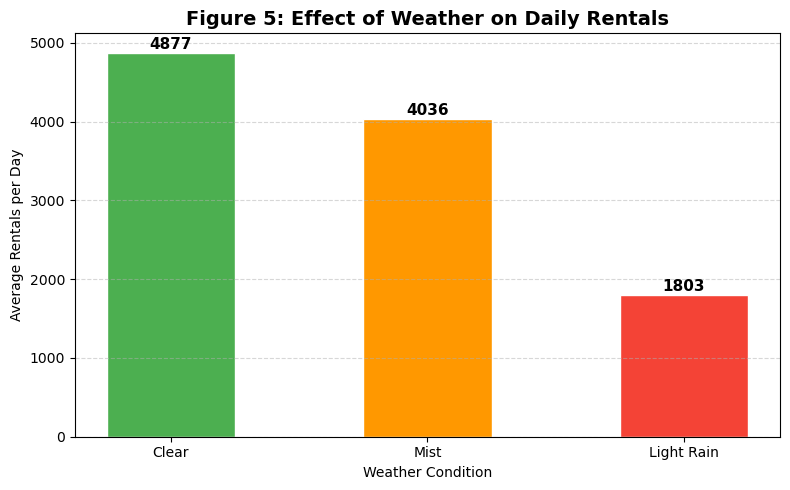

Observation: Clear weather has the most rentals.
Rain reduces rentals significantly. People avoid biking in bad weather.


In [23]:
# Create the bar chart
plt.figure(figsize=(8, 5))

colors = ['#4CAF50', '#FF9800', '#F44336']
bars = plt.bar(weather_avg.index, weather_avg.values,
               color=colors, width=0.5, edgecolor='white')

# Add value on top of each bar
for bar, val in zip(bars, weather_avg.values):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 50,
             str(round(val)),
             ha='center', fontsize=11, fontweight='bold')

plt.title('Figure 5: Effect of Weather on Daily Rentals', fontsize=14, fontweight='bold')
plt.ylabel('Average Rentals per Day')
plt.xlabel('Weather Condition')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print('Observation: Clear weather has the most rentals.')
print('Rain reduces rentals significantly. People avoid biking in bad weather.')

---
## ✅ STEP 11 — Prepare Data for Machine Learning

Before building models, we need to:
1. Select the **input features** (columns the model will use to learn)
2. Select the **target variable** (what the model will predict)
3. **Split** the data into training set and test set

**Training set** = data used to teach the model  
**Test set** = data used to check how good the model is

In [24]:
# Select input features (columns the model will use)
feature_columns = [
    'season',      # Season of the year
    'yr',          # Year (0=2011, 1=2012)
    'mnth',        # Month
    'holiday',     # Is it a holiday?
    'weekday',     # Day of the week
    'workingday',  # Is it a working day?
    'weathersit',  # Weather condition
    'temp',        # Temperature
    'atemp',       # Feeling temperature
    'hum',         # Humidity
    'windspeed'    # Wind speed
]

# X = input features (what the model looks at)
X = day[feature_columns]

# y = target variable (what the model needs to predict)
y = day['cnt']

print('Input features (X):')
print('  Shape:', X.shape, ' →', X.shape[0], 'days,', X.shape[1], 'features')
print()
print('Target variable (y):')
print('  Shape:', y.shape, ' →', y.shape[0], 'values to predict')

Input features (X):
  Shape: (731, 11)  → 731 days, 11 features

Target variable (y):
  Shape: (731,)  → 731 values to predict


In [25]:
# Split into training set (80%) and test set (20%)
# random_state=42 ensures we get the same split every time we run this
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    random_state=42      # For reproducibility
)

print('Data split done!')
print('Training set size:', X_train.shape[0], 'rows  (80%)')
print('Test set size    :', X_test.shape[0],  'rows  (20%)')

Data split done!
Training set size: 584 rows  (80%)
Test set size    : 147 rows  (20%)


---
## ✅ STEP 12 — Model 1: Linear Regression

**Linear Regression** is the simplest ML model.  
It tries to find a straight-line relationship between features and the output.

Steps:
1. Create the model
2. Train it on training data
3. Predict on test data
4. Measure how good the predictions are

In [26]:
# Step 1: Create the Linear Regression model
lr_model = LinearRegression()

# Step 2: Train the model using the training data
# fit() means "learn from this data"
lr_model.fit(X_train, y_train)

print('Linear Regression model trained!')

Linear Regression model trained!


In [27]:
# Step 3: Use the trained model to predict on test data
y_pred_lr = lr_model.predict(X_test)

# Show a few predictions vs actual values
print('Sample predictions vs actual values:')
print(f'{"Actual":>10}  {"Predicted":>10}')
for actual, predicted in zip(list(y_test[:8]), list(y_pred_lr[:8])):
    print(f'{actual:>10}  {predicted:>10.0f}')

Sample predictions vs actual values:
    Actual   Predicted
      6606        6220
      1550        1572
      3747        3044
      6041        4307
      7538        6766
      7264        7232
      1605         775
      2209        2140


In [28]:
# Step 4: Measure how good the model is

# R² Score: How much of the pattern did the model learn? (1.0 = perfect)
r2_lr = r2_score(y_test, y_pred_lr)

# RMSE: Average error in number of rentals (lower = better)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# MAE: Average absolute error (lower = better)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print('===== Linear Regression Results =====')
print(f'R² Score : {r2_lr:.4f}  (higher is better, max = 1.0)')
print(f'RMSE     : {rmse_lr:.1f}  (avg error in rentals, lower is better)')
print(f'MAE      : {mae_lr:.1f}  (avg absolute error, lower is better)')
print('======================================')

===== Linear Regression Results =====
R² Score : 0.8277  (higher is better, max = 1.0)
RMSE     : 831.3  (avg error in rentals, lower is better)
MAE      : 617.4  (avg absolute error, lower is better)


---
## ✅ STEP 13 — Model 2: Random Forest

**Random Forest** is a more powerful model.  
It creates many decision trees and combines them to make better predictions.  
It usually works better than Linear Regression for complex data.

`n_estimators=100` means we create 100 decision trees.

In [29]:
# Step 1: Create the Random Forest model
# n_estimators = number of decision trees to build
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Step 2: Train the model
rf_model.fit(X_train, y_train)

print('Random Forest model trained!')
print('(100 decision trees were built and combined)')

Random Forest model trained!
(100 decision trees were built and combined)


In [30]:
# Step 3: Predict on test data
y_pred_rf = rf_model.predict(X_test)

# Show a few predictions vs actual values
print('Sample predictions vs actual values:')
print(f'{"Actual":>10}  {"Predicted":>10}')
for actual, predicted in zip(list(y_test[:8]), list(y_pred_rf[:8])):
    print(f'{actual:>10}  {predicted:>10.0f}')

Sample predictions vs actual values:
    Actual   Predicted
      6606        6762
      1550        1546
      3747        3410
      6041        4761
      7538        7493
      7264        7341
      1605        1486
      2209        2342


In [31]:
# Step 4: Measure how good the model is
r2_rf   = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)

print('===== Random Forest Results =====')
print(f'R² Score : {r2_rf:.4f}  (higher is better, max = 1.0)')
print(f'RMSE     : {rmse_rf:.1f}  (avg error in rentals, lower is better)')
print(f'MAE      : {mae_rf:.1f}  (avg absolute error, lower is better)')
print('=================================')

===== Random Forest Results =====
R² Score : 0.8857  (higher is better, max = 1.0)
RMSE     : 677.1  (avg error in rentals, lower is better)
MAE      : 430.0  (avg absolute error, lower is better)


---
## ✅ STEP 14 — Compare Both Models

Now we compare both models side by side  
using a table and a bar chart.

In [32]:
# Create a comparison table using a DataFrame
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R² Score': [round(r2_lr, 4), round(r2_rf, 4)],
    'RMSE': [round(rmse_lr, 1), round(rmse_rf, 1)],
    'MAE': [round(mae_lr, 1), round(mae_rf, 1)]
})

print('===== Model Comparison Table =====')
print(results.to_string(index=False))
print()
print('Winner: Random Forest  (higher R², lower RMSE and MAE)')

===== Model Comparison Table =====
            Model  R² Score  RMSE   MAE
Linear Regression    0.8277 831.3 617.4
    Random Forest    0.8857 677.1 430.0

Winner: Random Forest  (higher R², lower RMSE and MAE)


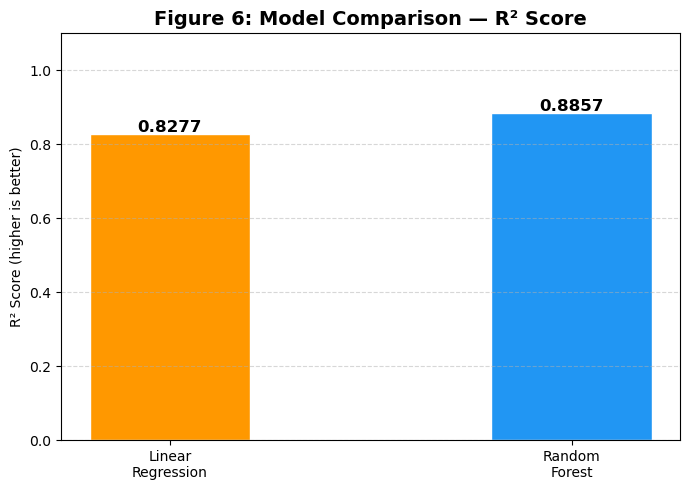

Random Forest gives a better R² score than Linear Regression.


In [33]:
# Bar chart comparing R² scores of both models
plt.figure(figsize=(7, 5))

model_names = ['Linear\nRegression', 'Random\nForest']
r2_values   = [r2_lr, r2_rf]
colors      = ['#FF9800', '#2196F3']

bars = plt.bar(model_names, r2_values, color=colors, width=0.4, edgecolor='white')

# Show the R² value on top of each bar
for bar, val in zip(bars, r2_values):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.005,
             str(round(val, 4)),
             ha='center', fontsize=12, fontweight='bold')

plt.title('Figure 6: Model Comparison — R² Score', fontsize=14, fontweight='bold')
plt.ylabel('R² Score (higher is better)')
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print('Random Forest gives a better R² score than Linear Regression.')

---
## ✅ STEP 15 — Chart 7: Actual vs Predicted

This scatter chart shows how close the model's predictions  
are to the actual values.

- Each dot = one day in the test set
- Red dashed line = perfect prediction (actual = predicted)
- Dots close to the red line = good predictions

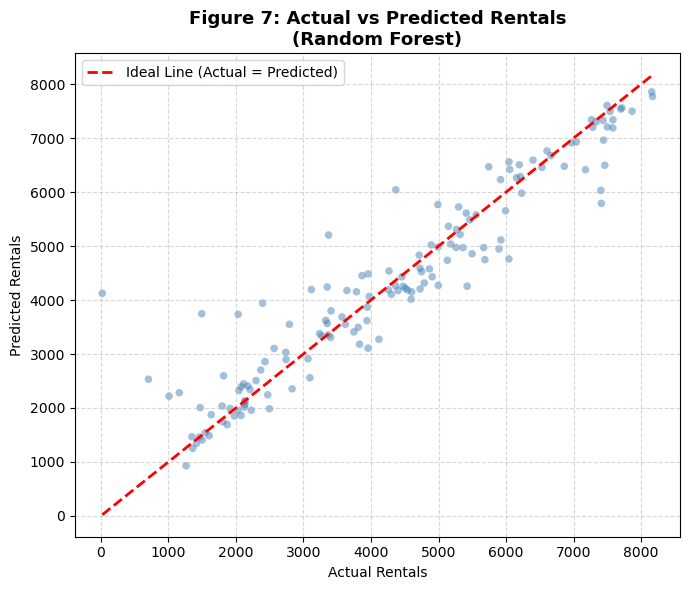

Observation: Most dots are close to the red line.
This means the Random Forest model predicts well.


In [34]:
# Actual vs Predicted chart for Random Forest
plt.figure(figsize=(7, 6))

# Plot each test day as a dot
plt.scatter(y_test, y_pred_rf,
            color='steelblue', alpha=0.5, s=30, edgecolors='none')

# Draw the ideal line (where actual = predicted)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2, label='Ideal Line (Actual = Predicted)')

plt.title('Figure 7: Actual vs Predicted Rentals\n(Random Forest)', fontsize=13, fontweight='bold')
plt.xlabel('Actual Rentals')
plt.ylabel('Predicted Rentals')
plt.legend(fontsize=10)
plt.grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print('Observation: Most dots are close to the red line.')
print('This means the Random Forest model predicts well.')

---
## ✅ STEP 16 — Final Summary

Let us print a final summary of everything we found in this project.

In [35]:
print('=' * 55)
print('      BIKE SHARING PROJECT — FINAL SUMMARY')
print('=' * 55)

print()
print('DATASET FACTS')
print('  Total records         :', day.shape[0], 'days')
print('  Total rentals         :', day['cnt'].sum())
print('  Average rentals/day   :', round(day['cnt'].mean(), 1))
print('  Max rentals in a day  :', day['cnt'].max())
print('  Min rentals in a day  :', day['cnt'].min())

print()
print('EDA FINDINGS')
print('  1. Rentals grew from 2011 to 2012')
print('  2. Fall has highest rentals, Winter has lowest')
print('  3. 81.2% rentals by registered users (commuters)')
print('  4. Registered users peak at 8 AM and 5-6 PM')
print('  5. Clear weather = more rentals, rain = less rentals')

print()
print('MODEL RESULTS')
print(f'  Linear Regression : R² = {r2_lr:.4f}, RMSE = {rmse_lr:.1f}, MAE = {mae_lr:.1f}')
print(f'  Random Forest     : R² = {r2_rf:.4f}, RMSE = {rmse_rf:.1f}, MAE = {mae_rf:.1f}')

print()
print('BEST MODEL: Random Forest')
print(f'  It predicts with ~{r2_rf*100:.1f}% accuracy (R² score)')

print()
print('=' * 55)
print('           Project Complete!')
print('=' * 55)

      BIKE SHARING PROJECT — FINAL SUMMARY

DATASET FACTS
  Total records         : 731 days
  Total rentals         : 3292679
  Average rentals/day   : 4504.3
  Max rentals in a day  : 8714
  Min rentals in a day  : 22

EDA FINDINGS
  1. Rentals grew from 2011 to 2012
  2. Fall has highest rentals, Winter has lowest
  3. 81.2% rentals by registered users (commuters)
  4. Registered users peak at 8 AM and 5-6 PM
  5. Clear weather = more rentals, rain = less rentals

MODEL RESULTS
  Linear Regression : R² = 0.8277, RMSE = 831.3, MAE = 617.4
  Random Forest     : R² = 0.8857, RMSE = 677.1, MAE = 430.0

BEST MODEL: Random Forest
  It predicts with ~88.6% accuracy (R² score)

           Project Complete!


---
## BONUS — Predict for a New Day

You can change the values below and predict  
how many bikes will be rented on any day you want!

In [36]:
# ── Change these values to predict for a different day ──

new_day = pd.DataFrame([{
    'season'     : 3,     # 1=Spring, 2=Summer, 3=Fall, 4=Winter
    'yr'         : 1,     # 0=2011, 1=2012
    'mnth'       : 10,    # Month (1 to 12)
    'holiday'    : 0,     # 1=Holiday, 0=Not a holiday
    'weekday'    : 3,     # 0=Sun, 1=Mon, 2=Tue, 3=Wed, 4=Thu, 5=Fri, 6=Sat
    'workingday' : 1,     # 1=Working day, 0=Weekend or holiday
    'weathersit' : 1,     # 1=Clear, 2=Mist, 3=Light Rain
    'temp'       : 0.6,   # Temperature normalized (0.6 = about 25°C)
    'atemp'      : 0.58,  # Feeling temperature normalized
    'hum'        : 0.55,  # Humidity normalized (0.55 = 55%)
    'windspeed'  : 0.15   # Wind speed normalized
}])

# Make predictions using both models
pred_lr = lr_model.predict(new_day)[0]
pred_rf = rf_model.predict(new_day)[0]

print('Prediction for: Fall, October, Wednesday, Clear Sky, ~25°C')
print()
print(f'  Linear Regression predicts : {pred_lr:.0f} rentals')
print(f'  Random Forest predicts     : {pred_rf:.0f} rentals  ← (more reliable)')

Prediction for: Fall, October, Wednesday, Clear Sky, ~25°C

  Linear Regression predicts : 6702 rentals
  Random Forest predicts     : 7766 rentals  ← (more reliable)


---
## My Project is Completed !

Here is what i did in this notebook:

| Step | What You Did |
|------|--------------|
| Step 1 | Imported all libraries |
| Step 2 | Loaded day.csv and hour.csv |
| Step 3 | Checked data types, missing values, duplicates |
| Step 4 | Added readable labels, parsed dates |
| Step 5 | Printed basic statistics |
| Step 6 | Made monthly trend chart |
| Step 7 | Made season bar chart |
| Step 8 | Made user type pie chart |
| Step 9 | Made hourly pattern chart |
| Step 10 | Made weather effect chart |
| Step 11 | Prepared features and split data |
| Step 12 | Trained Linear Regression and measured it |
| Step 13 | Trained Random Forest and measured it |
| Step 14 | Compared both models with table and chart |
| Step 15 | Plotted Actual vs Predicted chart |
| Step 16 | Printed final summary |
| Bonus | Predicted rentals for a custom day |

---
**Dataset:** UCI Machine Learning Repository — Bike Sharing Dataset  
**Citation:** Fanaee-T, Hadi, and Gama, Joao (2013). *Event labeling combining ensemble detectors and background knowledge.* Progress in Artificial Intelligence, Springer.